In [1]:
# Core Deep Learning
!pip install -q torch torchvision

# DICOM handling
!pip install -q pydicom

# Image processing and transformations
!pip install -q pillow opencv-python

# Data handling and progress visualization
!pip install -q numpy matplotlib tqdm scikit-learn

# Optional: for model summary visualization
!pip install -q torchsummary


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 18.5 MB/s eta 0:00:00


In [2]:
# -------------------------------
# Core PyTorch and Vision Libraries
# -------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split

# -------------------------------
# Optimization & Learning Rate Schedulers
# -------------------------------
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# -------------------------------
# Metrics & Evaluation
# -------------------------------
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -------------------------------
# Image and Medical Data Handling
# -------------------------------
import numpy as np
import cv2
import os
import pydicom
from PIL import Image

# -------------------------------
# Visualization and Progress Display
# -------------------------------
import matplotlib.pyplot as plt
from tqdm import tqdm

# -------------------------------
# Model Summary (for overview)
# -------------------------------
from torchsummary import summary


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

# -------------------------------
# Dataset Root Directory
# -------------------------------
data_root = '/content/drive/MyDrive/Major project Final models/major project dataset'

# Check available folders or patient cases in alphabetical order
print("Classes / Patient Folders Found :")
folders = sorted(os.listdir(data_root))
print(folders)


Classes / Patient Folders Found :
['.ipynb_checkpoints', 'patient 1', 'patient 2', 'patient 3', 'patient 4', 'patient 5', 'patient 6', 'patient 7', 'suv_values_with_labels.csv']


In [5]:
# -------------------------------
# Load DICOM Images, Compute SUVmax, Assign Labels & Save CSV
# -------------------------------
import os
import pandas as pd
import pydicom
import numpy as np

# Define dataset root and output CSV path
data_root = '/content/drive/MyDrive/Major project Final models/major project dataset'
output_csv = os.path.join(data_root, 'suv_values_with_labels.csv')

# -------------------------------
# Helper Function: Compute SUVmax
# -------------------------------
def calculate_suv(dcm, body_weight_kg=70.0):
    """Compute SUVmax from PET DICOM with proper unit handling."""
    try:
        pixel_array = dcm.pixel_array.astype(np.float32)
        slope = float(getattr(dcm, "RescaleSlope", 1.0))
        intercept = float(getattr(dcm, "RescaleIntercept", 0.0))
        activity = pixel_array * slope + intercept  # raw activity

        # Use SUVConversionFactor if present
        if hasattr(dcm, 'SUVConversionFactor'):
            suv_array = activity * float(dcm.SUVConversionFactor)
            return np.max(suv_array)

        # Otherwise compute SUV manually
        if hasattr(dcm, "RadiopharmaceuticalInformationSequence"):
            rph = dcm.RadiopharmaceuticalInformationSequence[0]
            injected_dose_Bq = float(getattr(rph, "RadionuclideTotalDose", 370e6))
        else:
            injected_dose_Bq = 370e6  # fallback 370 MBq

        # Convert injected dose to kBq
        injected_dose_kBq = injected_dose_Bq / 1000.0
        body_weight_g = body_weight_kg * 1000.0
        activity_kBq_per_ml = activity / 1000.0
        suv_array = activity_kBq_per_ml / (injected_dose_kBq / body_weight_g)

        return np.max(suv_array)

    except Exception as e:
        print(f"⚠️ Error in file: {getattr(dcm, 'filename', 'Unknown')} | {e}")
        return 0.0

# -------------------------------
# Iterate through DICOMs and collect SUVmax
# -------------------------------
dicom_paths = []
suv_values = []

for patient in sorted(os.listdir(data_root)):
    patient_path = os.path.join(data_root, patient)
    if os.path.isdir(patient_path):
        for fname in os.listdir(patient_path):
            if fname.endswith('.dcm'):
                fpath = os.path.join(patient_path, fname)
                try:
                    dcm = pydicom.dcmread(fpath)
                    suv_max = calculate_suv(dcm)
                    dicom_paths.append(fpath)
                    suv_values.append(suv_max)
                except Exception as e:
                    print(f"Error reading {fpath}: {e}")

# -------------------------------
# Set Fixed SUV Threshold
# -------------------------------
threshold = 2.5
print(f"\n📊 Fixed SUV Threshold = {threshold}")

# Assign labels and print each DICOM info
labels = []
print("\nDICOM Path | SUVmax | Assigned Label")
for path, suv in zip(dicom_paths, suv_values):
    label = 1 if suv > threshold else 0  # 1 = Tumor, 0 = Fibrosis
    labels.append(label)
    print(f"{os.path.basename(path)} | {suv:.3f} | {'Tumor' if label==1 else 'Fibrosis'}")

# -------------------------------
# Create and Save DataFrame
# -------------------------------
df = pd.DataFrame({
    'dicom_path': dicom_paths,
    'SUVmax': suv_values,
    'label': labels
})
df.to_csv(output_csv, index=False)
print(f"\n💾 CSV with labels saved successfully at: {output_csv}")

# -------------------------------
# Display Summary
# -------------------------------
print("\n✅ First few entries:")
print(df.head())

print("\n✅ Last few entries:")
print(df.tail())

print(f"\nTotal DICOM slices processed: {len(df)}")

# Check class balance
print("\n📈 Label Distribution:")
print(df['label'].value_counts().rename({0: 'Fibrosis (Low SUV)', 1: 'Tumor (High SUV)'}))



📊 Fixed SUV Threshold = 2.5

DICOM Path | SUVmax | Assigned Label
1-03.dcm | 1.628 | Fibrosis
1-04.dcm | 1.837 | Fibrosis
1-10.dcm | 2.124 | Fibrosis
1-06.dcm | 2.159 | Fibrosis
1-02.dcm | 2.030 | Fibrosis
1-01.dcm | 2.397 | Fibrosis
1-08.dcm | 1.905 | Fibrosis
1-05.dcm | 2.123 | Fibrosis
1-09.dcm | 2.067 | Fibrosis
1-07.dcm | 2.184 | Fibrosis
1-19.dcm | 1.474 | Fibrosis
1-15.dcm | 1.598 | Fibrosis
1-20.dcm | 1.366 | Fibrosis
1-24.dcm | 1.181 | Fibrosis
1-16.dcm | 1.948 | Fibrosis
1-17.dcm | 1.674 | Fibrosis
1-27.dcm | 0.922 | Fibrosis
1-21.dcm | 1.655 | Fibrosis
1-18.dcm | 1.699 | Fibrosis
1-13.dcm | 0.899 | Fibrosis
1-23.dcm | 1.373 | Fibrosis
1-12.dcm | 1.344 | Fibrosis
1-22.dcm | 1.553 | Fibrosis
1-14.dcm | 1.364 | Fibrosis
1-11.dcm | 1.953 | Fibrosis
1-25.dcm | 1.271 | Fibrosis
1-26.dcm | 1.152 | Fibrosis
1-29.dcm | 0.991 | Fibrosis
1-33.dcm | 2.841 | Tumor
1-35.dcm | 4.526 | Tumor
1-36.dcm | 4.595 | Tumor
1-37.dcm | 1.843 | Fibrosis
1-34.dcm | 3.082 | Tumor
1-32.dcm | 1.837 | Fi

In [6]:
import os
from collections import defaultdict

# Dataset root directory
data_root = '/content/drive/MyDrive/Major project Final models/major project dataset'

# Get class/patient folder names
classes = sorted(os.listdir(data_root))

# Dictionary to store counts
class_counts = defaultdict(int)

# Count number of DICOM files in each folder
for class_name in classes:
    class_dir = os.path.join(data_root, class_name)
    if os.path.isdir(class_dir):
        dicom_files = [f for f in os.listdir(class_dir) if f.endswith('.dcm')]
        class_counts[class_name] = len(dicom_files)

# Print counts per class/patient
print("📂 DICOM Counts per Patient/Class:")
for cls, count in class_counts.items():
    print(f"{cls:25s} : {count} DICOM slices")


📂 DICOM Counts per Patient/Class:
.ipynb_checkpoints        : 0 DICOM slices
patient 1                 : 83 DICOM slices
patient 2                 : 83 DICOM slices
patient 3                 : 83 DICOM slices
patient 4                 : 83 DICOM slices
patient 5                 : 83 DICOM slices
patient 6                 : 83 DICOM slices
patient 7                 : 83 DICOM slices


In [7]:
from torch.utils.data import Dataset
import torch
import pydicom
from PIL import Image
import numpy as np

class BreastPETDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        dcm_path = self.df.loc[idx, 'dicom_path']
        suv = self.df.loc[idx, 'SUVmax']
        label = self.df.loc[idx, 'label']

        # Load DICOM image
        dcm = pydicom.dcmread(dcm_path)
        img = dcm.pixel_array.astype(np.float32)

        # Clip extreme values for PET
        img = np.clip(img, 0, 20)

        # Normalize to [0,1]
        img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5)

        # Convert to 3-channel RGB
        img = (img * 255).astype(np.uint8)
        img = Image.fromarray(img).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long), torch.tensor(suv, dtype=torch.float32)


In [8]:
from sklearn.model_selection import train_test_split

# Assuming 'df' contains columns: ['dicom_path', 'SUVmax', 'label']

# Stratified split to maintain class balance (e.g., 80% train, 20% validation)
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

# Display dataset sizes
print(f" Training samples: {len(train_df)}")
print(f" Validation samples: {len(val_df)}")

# Optional: check label distribution
print("\n Training label distribution:")
print(train_df['label'].value_counts())
print("\n Validation label distribution:")
print(val_df['label'].value_counts())


 Training samples: 464
 Validation samples: 117

 Training label distribution:
label
0    278
1    186
Name: count, dtype: int64

 Validation label distribution:
label
0    70
1    47
Name: count, dtype: int64


In [9]:
from torch.utils.data import DataLoader
from torchvision import transforms

# -------------------------------
# Define image transformations
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),   # augmentation
    transforms.RandomRotation(10),       # augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# -------------------------------
# Create Datasets
# -------------------------------
train_dataset = BreastPETDataset(train_df, transform=transform)
val_dataset = BreastPETDataset(val_df, transform=transform)

# -------------------------------
# Create DataLoaders
# -------------------------------
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

# -------------------------------
# Test a single batch
# -------------------------------
for images, labels, suvs in train_loader:
    print("Batch image tensor shape:", images.shape)  # [batch_size, 3, 224, 224]
    print("Batch label tensor shape:", labels.shape)  # [batch_size]
    print("Batch SUV tensor shape:", suvs.shape)      # [batch_size]
    print("Labels:", labels.tolist())
    print("SUV values:", suvs.tolist())
    break


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch image tensor shape: torch.Size([4, 3, 224, 224])
Batch label tensor shape: torch.Size([4])
Batch SUV tensor shape: torch.Size([4])
Labels: [0, 1, 1, 1]
SUV values: [1.8365541696548462, 2.813903570175171, 2.832033157348633, 6.388047695159912]


ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.3876]])


Epoch 1/10 [Training]:   0%|          | 0/58 [00:00<?, ?it/s]

ResNet feat shape: torch.Size([8, 512])
ViT feat shape: torch.Size([8, 96])
SUV shape: torch.Size([8, 1])
Fused shape: torch.Size([8, 609])
SUV values (first 5): tensor([[ 1.3867],
        [15.6406],
        [ 2.1593],
        [ 7.5552],
        [ 8.5139]])


Epoch 1/10 [Training]:   2%|▏         | 1/58 [00:02<02:37,  2.76s/it]

ResNet feat shape: torch.Size([8, 512])
ViT feat shape: torch.Size([8, 96])
SUV shape: torch.Size([8, 1])
Fused shape: torch.Size([8, 609])
SUV values (first 5): tensor([[ 3.1344],
        [ 1.6258],
        [ 1.8795],
        [ 1.7049],
        [16.4446]])


...

ResNet feat shape: torch.Size([8, 512])
ViT feat shape: torch.Size([8, 96])
SUV shape: torch.Size([8, 1])
Fused shape: torch.Size([8, 609])
SUV values (first 5): tensor([[1.8513],
        [1.4292],
        [1.7937],
        [1.0408],
        [1.3737]])


Epoch 10/10 [Validation]:  93%|█████████▎| 14/15 [00:13<00:00,  1.21it/s]

ResNet feat shape: torch.Size([8, 512])
ViT feat shape: torch.Size([8, 96])
SUV shape: torch.Size([8, 1])
Fused shape: torch.Size([8, 609])
SUV values (first 5): tensor([[1.1153],
        [0.8497],
        [2.4265],
        [3.4317],
        [8.5723]])


Epoch 10/10 [Validation]: 100%|██████████| 15/15 [00:13<00:00,  1.10it/s]

ResNet feat shape: torch.Size([5, 512])
ViT feat shape: torch.Size([5, 96])
SUV shape: torch.Size([5, 1])
Fused shape: torch.Size([5, 609])
SUV values (first 5): tensor([[5.8363],
        [0.7229],
        [0.7994],
        [1.7019],
        [1.2735]])

Epoch 10/10 Summary:
Train Loss: 0.0374 | Train Acc: 94.83%
Val   Loss: 0.0353 | Val   Acc: 96.58%

Early stopping triggered at epoch 10.
Loaded best model based on validation loss.

Classification Report:
              precision    recall  f1-score   support

    Fibrosis     0.9459    1.0000    0.9722        70
       Tumor     1.0000    0.9149    0.9556        47

    accuracy                         0.9658       117
   macro avg     0.9730    0.9574    0.9639       117
weighted avg     0.9677    0.9658    0.9655       117



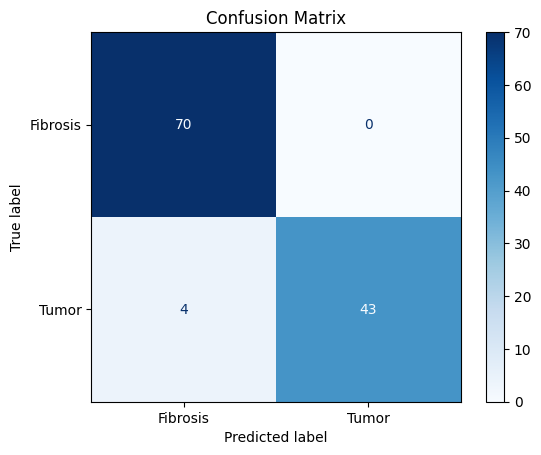

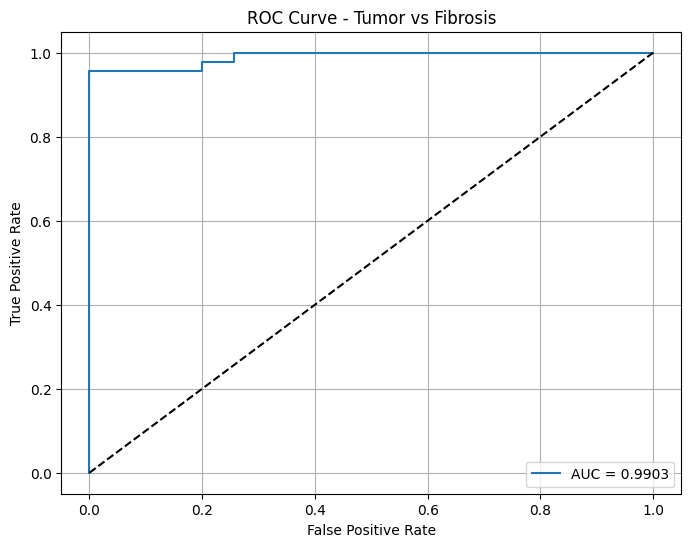

In [ ]:
!pip install torchinfo

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models, transforms
from transformers import ViTConfig, ViTForImageClassification
from torchinfo import summary
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# ----------------- Device -----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------- Focal Loss -----------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# ----------------- Hybrid Model (Images + SUV) -----------------
# ----------------- Hybrid Model (Images + SUV) -----------------
class HybridResNetViT(nn.Module):
    def __init__(self, resnet_model, vit_model):
        super(HybridResNetViT, self).__init__()
        self.resnet_feature_extractor = nn.Sequential(*list(resnet_model.children())[:-1])  # Remove FC
        self.vit_feature_extractor = vit_model.vit  # ViT encoder

        # Classifier using MLP (including SUV)
        self.classifier = nn.Sequential(
            nn.Linear(512 + 96 + 1, 256),  # +1 for SUV input
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)  # 2 classes
        )

    def forward(self, x, suv):
        # ResNet features
        resnet_feat = self.resnet_feature_extractor(x)
        resnet_feat = resnet_feat.view(resnet_feat.size(0), -1)

        # ViT features
        vit_outputs = self.vit_feature_extractor(pixel_values=x)
        vit_feat = vit_outputs.last_hidden_state[:, 0, :]  # CLS token

        # Concatenate features with SUV
        suv = suv.view(-1,1)  # Ensure shape [B,1]

        # -------- Debug Prints --------
        print("ResNet feat shape:", resnet_feat.shape)
        print("ViT feat shape:", vit_feat.shape)
        print("SUV shape:", suv.shape)
        print("Fused shape:", torch.cat((resnet_feat, vit_feat, suv), dim=1).shape)
        print("SUV values (first 5):", suv[:5])
        # ------------------------------

        fused = torch.cat((resnet_feat, vit_feat, suv), dim=1)

        # Classifier
        out = self.classifier(fused)
        return out

# ----------------- Instantiate Models -----------------
resnet_model = models.resnet18(weights=None)
resnet_model.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)

custom_vit_config = ViTConfig(
    image_size=224,
    patch_size=16,
    num_channels=3,
    num_labels=2,
    hidden_size=96,
    num_hidden_layers=3,
    num_attention_heads=2,
    intermediate_size=512,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)

vit_model = ViTForImageClassification(custom_vit_config)
hybrid_model = HybridResNetViT(resnet_model=resnet_model, vit_model=vit_model)
hybrid_model.to(device)

# ----------------- Model Summary -----------------
summary(hybrid_model, input_size=[(1,3,224,224),(1,1)])

# ----------------- Loss & Optimizer -----------------
criterion = FocalLoss(alpha=1.0, gamma=2.0)
optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=1e-4)

# ----------------- Training Settings -----------------
num_epochs = 10
patience = 3
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None
class_names = ['Fibrosis', 'Tumor']

# ----------------- DataLoaders -----------------
# Assuming you have train_dataset and val_dataset ready using BreastPETDataset
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# ----------------- Training Loop -----------------
for epoch in range(num_epochs):
    hybrid_model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels, suvs in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
        images, labels, suvs = images.to(device), labels.to(device), suvs.to(device)

        optimizer.zero_grad()
        outputs = hybrid_model(images, suvs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    # ----------------- Validation -----------------
    hybrid_model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    all_preds, all_probs, all_targets = [], [], []

    with torch.no_grad():
        for images, labels, suvs in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]"):
            images, labels, suvs = images.to(device), labels.to(device), suvs.to(device)

            outputs = hybrid_model(images, suvs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val

    print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {avg_val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

    # ----------------- Early Stopping -----------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = hybrid_model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            break

# ----------------- Load Best Model -----------------
if best_model_state:
    hybrid_model.load_state_dict(best_model_state)
    print("Loaded best model based on validation loss.")

# ----------------- Evaluation -----------------
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_targets = np.array(all_targets)

print("\nClassification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

auc_score = roc_auc_score(all_targets, all_probs[:, 1])
fpr, tpr, _ = roc_curve(all_targets, all_probs[:, 1])

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tumor vs Fibrosis")
plt.legend()
plt.grid(True)
plt.show()


ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.3382]], device='cuda:0')


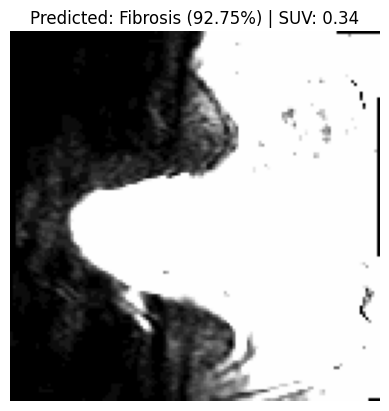

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2492]], device='cuda:0')


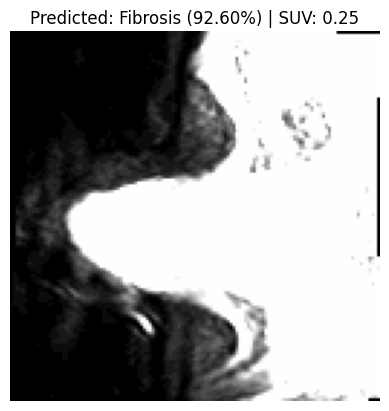

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2479]], device='cuda:0')


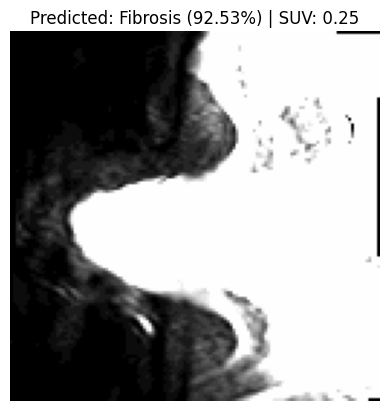

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2342]], device='cuda:0')


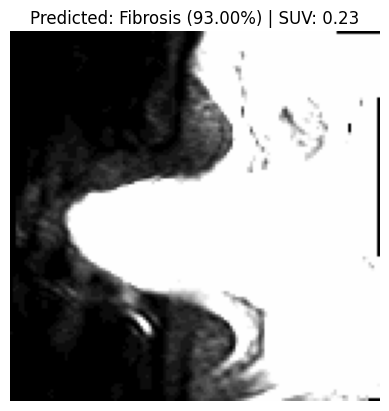

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2423]], device='cuda:0')


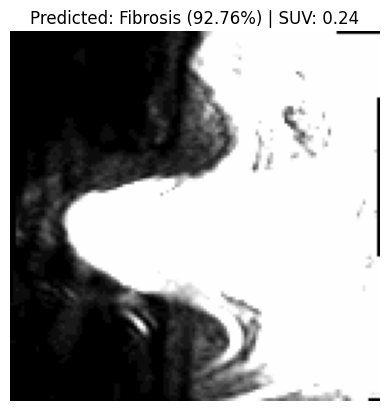

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2429]], device='cuda:0')


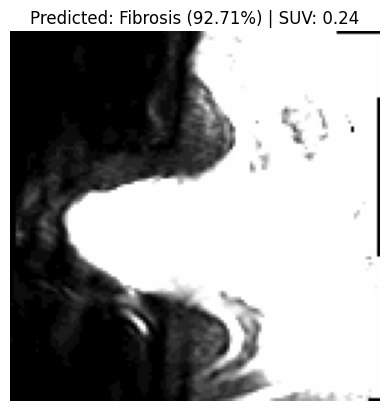

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2434]], device='cuda:0')


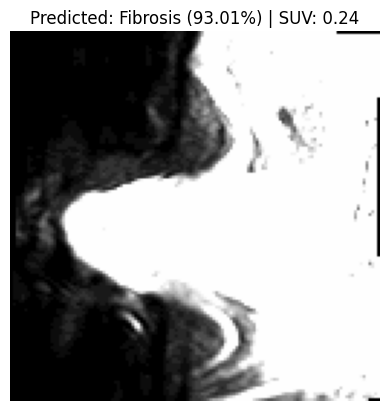

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.3828]], device='cuda:0')


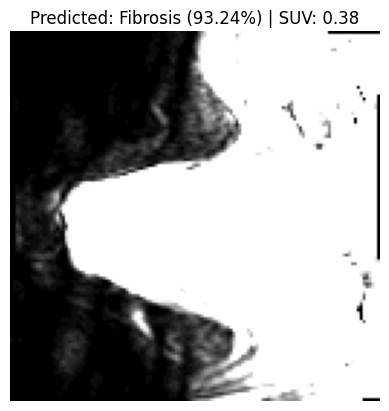

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2323]], device='cuda:0')


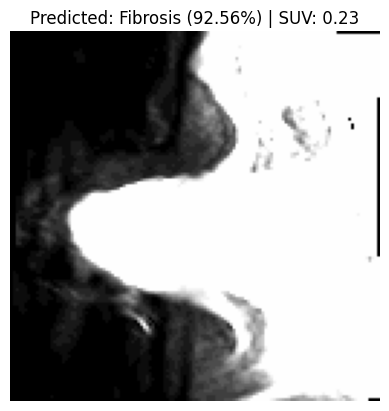

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.2772]], device='cuda:0')


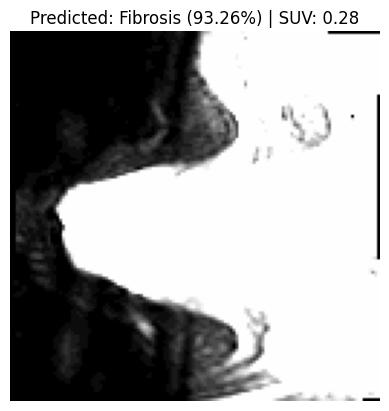

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.8051]], device='cuda:0')


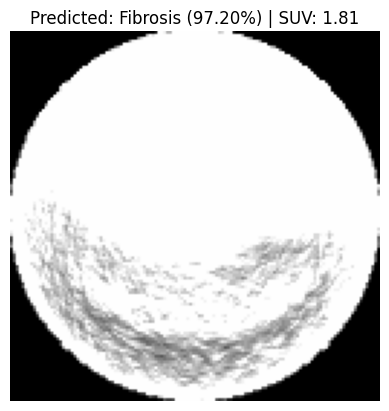

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.7720]], device='cuda:0')


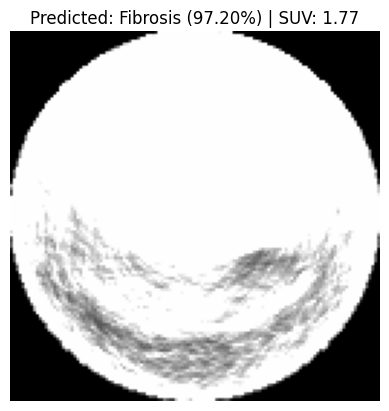

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.7600]], device='cuda:0')


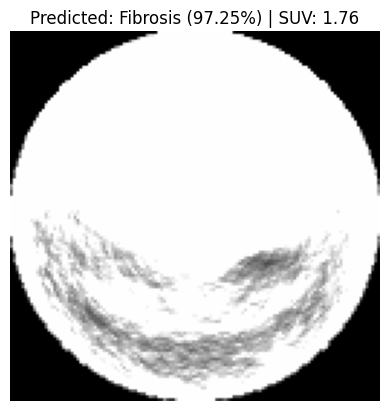

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.7831]], device='cuda:0')


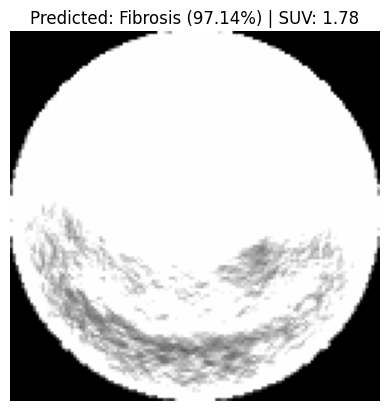

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.8080]], device='cuda:0')


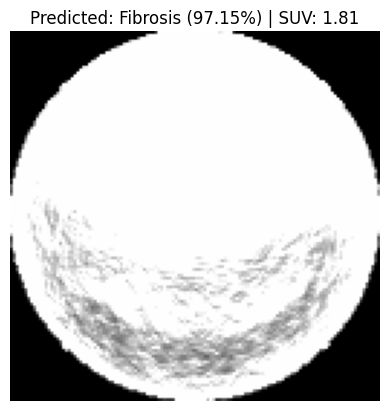

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.7929]], device='cuda:0')


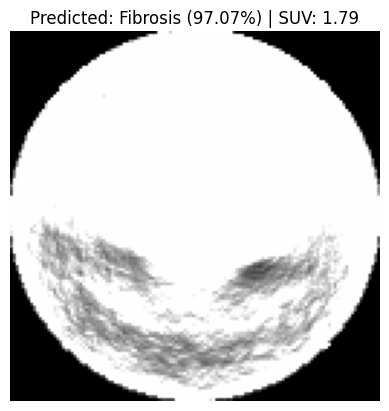

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.7521]], device='cuda:0')


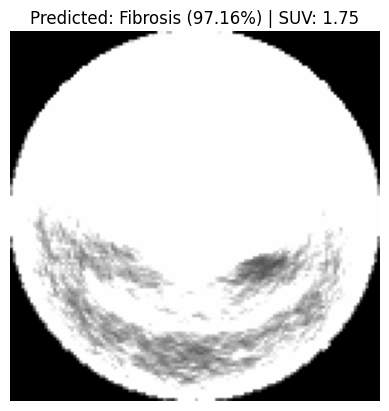

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.7116]], device='cuda:0')


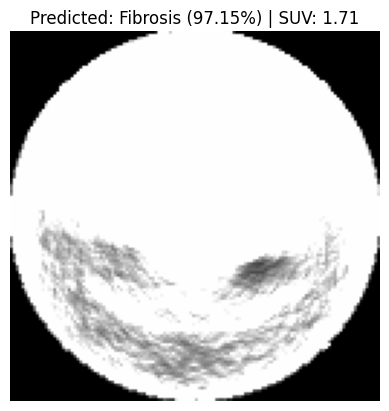

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.6924]], device='cuda:0')


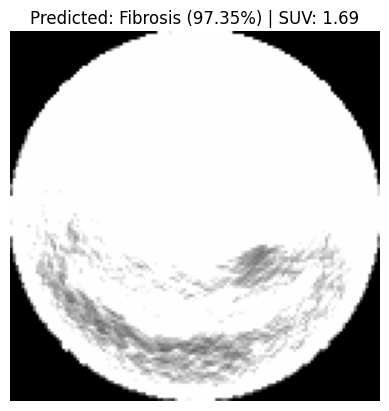

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.8602]], device='cuda:0')


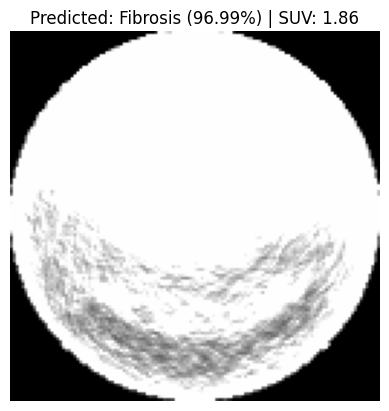

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.4894]], device='cuda:0')


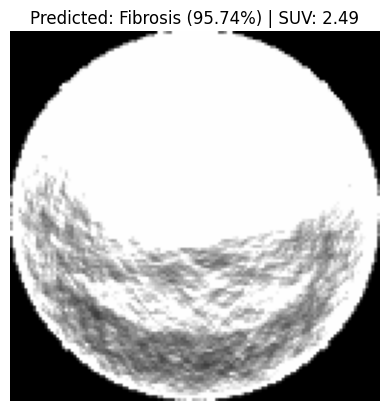

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.9148]], device='cuda:0')


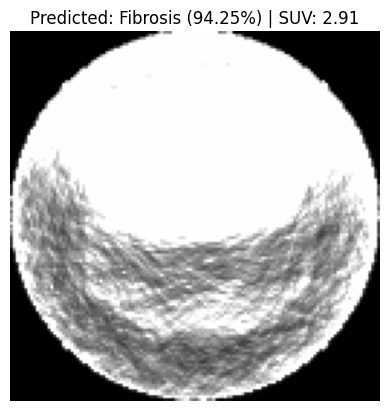

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.0375]], device='cuda:0')


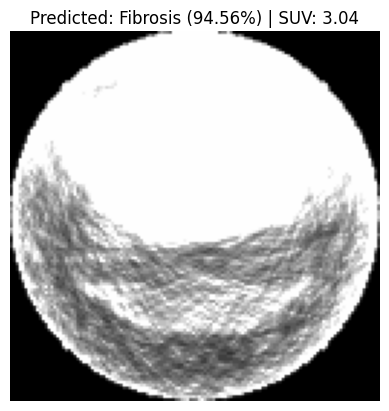

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.9997]], device='cuda:0')


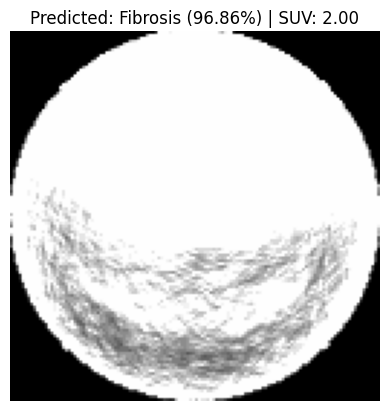

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.4198]], device='cuda:0')


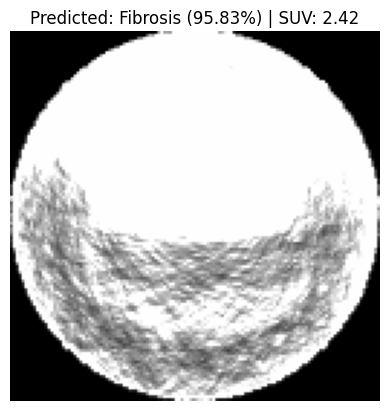

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.6055]], device='cuda:0')


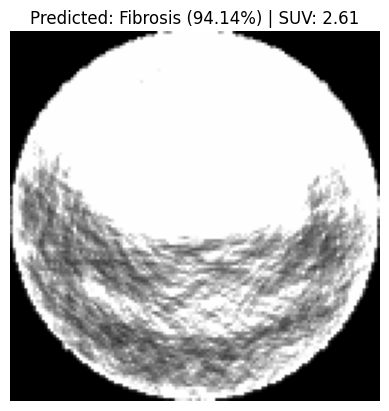

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.5492]], device='cuda:0')


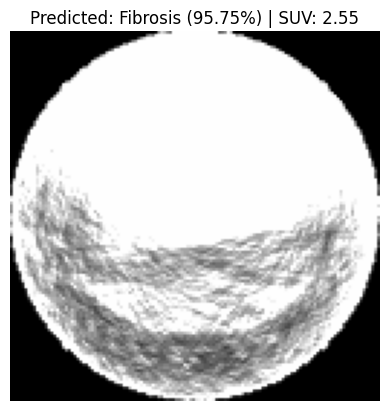

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.1552]], device='cuda:0')


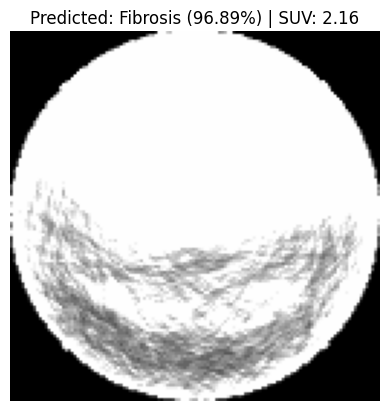

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.3552]], device='cuda:0')


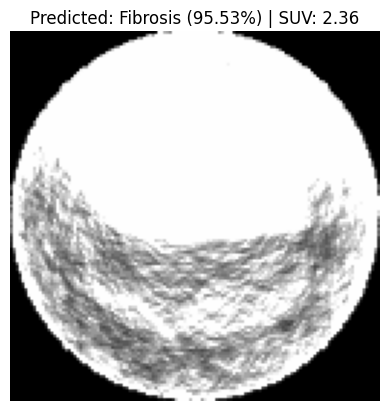

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.7100]], device='cuda:0')


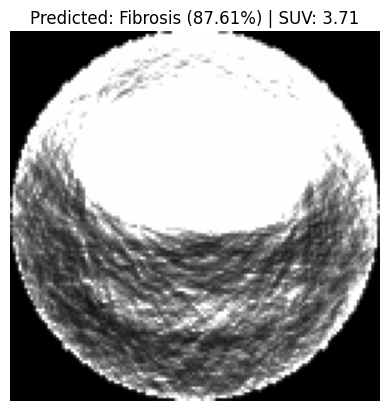

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.2832]], device='cuda:0')


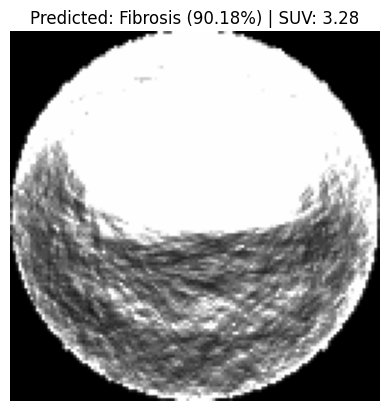

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.3618]], device='cuda:0')


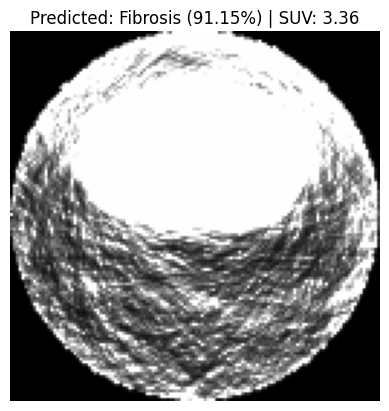

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.0436]], device='cuda:0')


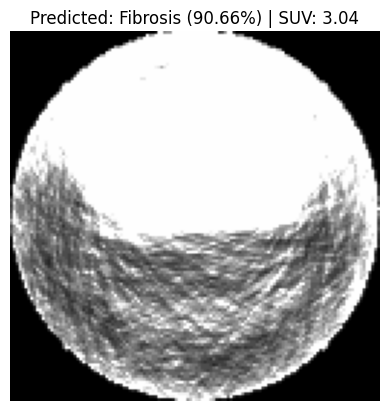

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.5756]], device='cuda:0')


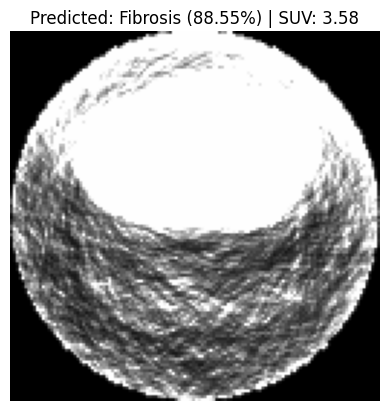

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[3.8468]], device='cuda:0')


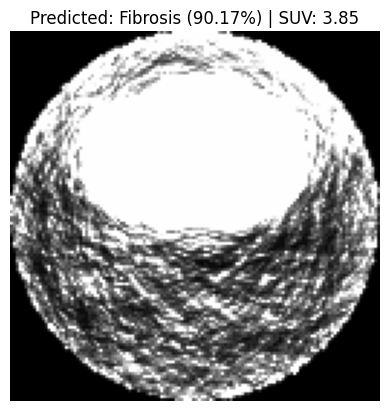

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.6145]], device='cuda:0')


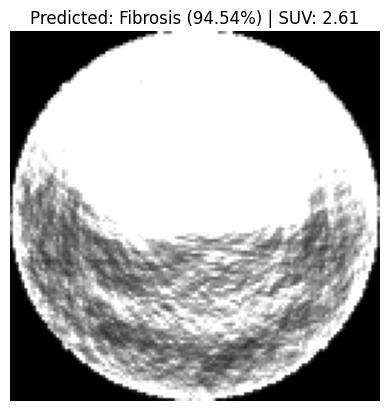

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[7.5497]], device='cuda:0')


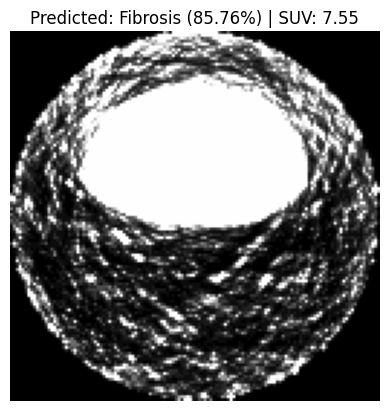

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[4.0696]], device='cuda:0')


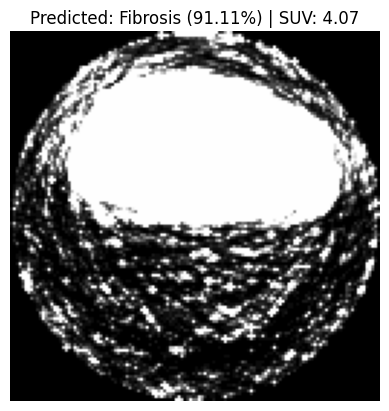

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.9305]], device='cuda:0')


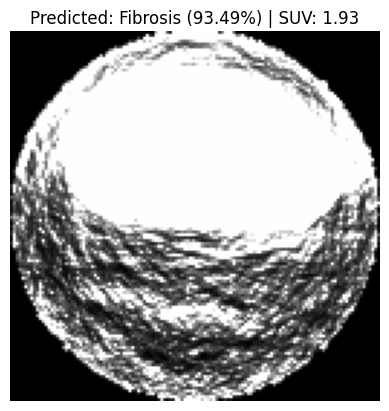

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[2.1859]], device='cuda:0')


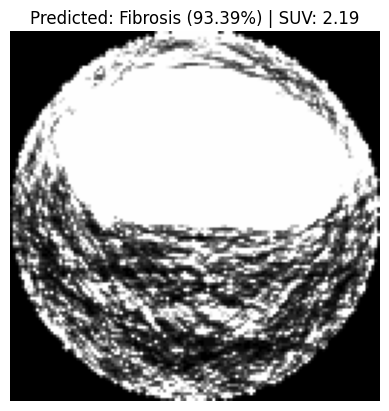

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.0305]], device='cuda:0')


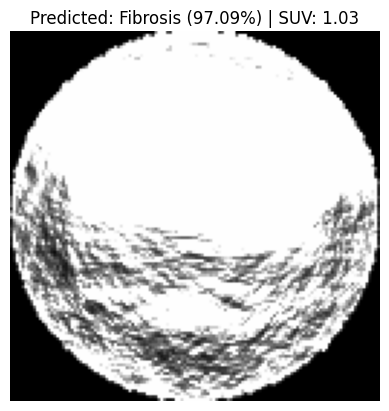

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.9388]], device='cuda:0')


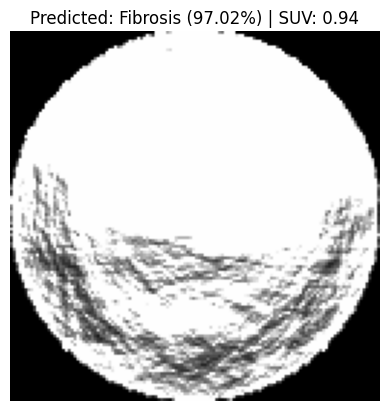

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.9173]], device='cuda:0')


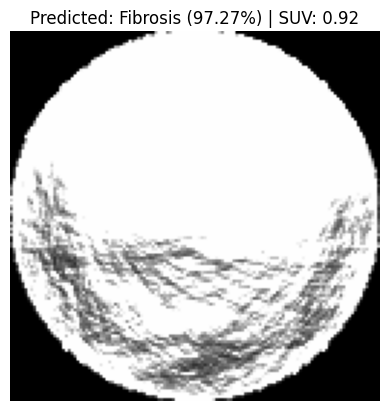

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[1.0371]], device='cuda:0')


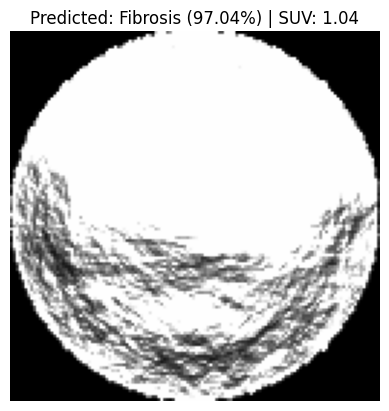

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.7653]], device='cuda:0')


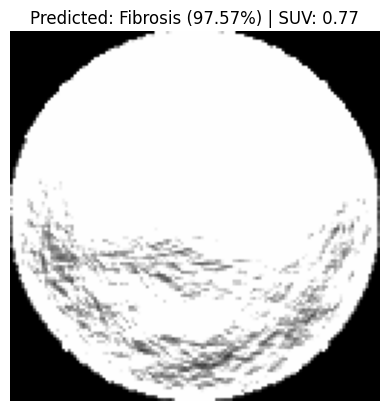

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.7818]], device='cuda:0')


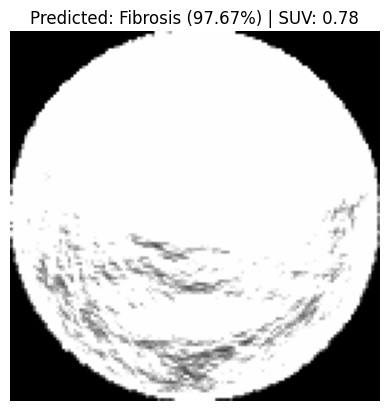

ResNet feat shape: torch.Size([1, 512])
ViT feat shape: torch.Size([1, 96])
SUV shape: torch.Size([1, 1])
Fused shape: torch.Size([1, 609])
SUV values (first 5): tensor([[0.7725]], device='cuda:0')


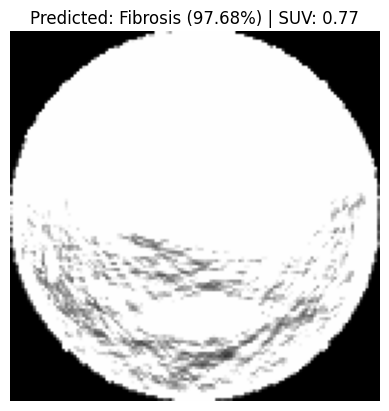

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np
import pydicom

# ------------------- Device -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hybrid_model.eval()  # Set model to evaluation mode

# ------------------- Image Folder -------------------
test_folder = "/content/drive/MyDrive/Major project Final models/test images"
image_paths = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith(".dcm")]

# ------------------- Preprocessing -------------------
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # standard ImageNet mean
                         std=[0.229, 0.224, 0.225])
])

# ------------------- Class Names -------------------
class_names = ['Fibrosis', 'Tumor']

# ------------------- DICOM → PIL Image -------------------
def dicom_to_pil(dicom_path):
    ds = pydicom.dcmread(dicom_path)
    img_array = ds.pixel_array.astype(np.float32)

    # Clip extreme PET values and normalize
    img_array = np.clip(img_array, 0, 20)
    img_array -= np.min(img_array)
    img_array /= (np.max(img_array) + 1e-5)
    img_array *= 255.0

    # Convert to 3-channel RGB
    img_array = np.stack([img_array]*3, axis=-1).astype(np.uint8)
    return Image.fromarray(img_array)

# ------------------- Inference & Display -------------------
for img_path in image_paths:
    # Load DICOM
    img = dicom_to_pil(img_path)
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    # Compute SUV
    dcm = pydicom.dcmread(img_path)
    suv_value = calculate_suv(dcm)  # your existing SUV function
    suv_tensor = torch.tensor([[suv_value]], dtype=torch.float32).to(device)

    # Model prediction
    with torch.no_grad():
        outputs = hybrid_model(input_tensor, suv_tensor)
        probs = F.softmax(outputs, dim=1)
        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_class].item()

    # Display
    plt.imshow(np.array(img))
    plt.title(f"Predicted: {class_names[pred_class]} ({confidence*100:.2f}%) | SUV: {suv_value:.2f}")
    plt.axis('off')
    plt.show()
